In [1]:
# 1. Clone the repo
!git clone https://github.com/fastai/course-v3.git

# 2. Move the exp folder to your current directory
!mv course-v3/nbs/dl2/exp .

Cloning into 'course-v3'...
remote: Enumerating objects: 5909, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5909 (delta 9), reused 1 (delta 1), pack-reused 5893 (from 1)
Receiving objects: 100% (5909/5909), 263.04 MiB | 25.78 MiB/s, done.
Resolving deltas: 100% (3259/3259), done.
Updating files: 100% (887/887), done.


In [3]:
from exp.nb_05 import *

In [4]:
import os
import urllib.request

In [5]:
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz'

# Set path to the local Colab content folder
path = Path('mnist.pkl.gz')

if not path.exists():
    print("Downloading MNIST pkl.gz...")
    urllib.request.urlretrieve(MNIST_URL, path)

print(f"File downloaded to: {path.absolute()}")

File downloaded to: /content/mnist.pkl.gz


In [6]:
with gzip.open(path, 'rb') as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

---

## Early stopping
### Better callback cancellation

In [8]:
x_train,y_train,x_valid,y_valid = get_data(path)
train_ds,valid_ds = Dataset(x_train, y_train),Dataset(x_valid, y_valid)
nh,bs = 50,512
c = y_train.max().item()+1
loss_func = F.cross_entropy

In [9]:
data = DataBunch(*get_dls(train_ds, valid_ds, bs), c)

In [10]:
class Callback():
    _order=0
    def set_runner(self, run): self.run=run
    def __getattr__(self, k): return getattr(self.run, k)

    @property
    def name(self):
        name = re.sub(r'Callback$', '', self.__class__.__name__)
        return camel2snake(name or 'callback')

    def __call__(self, cb_name):
        f = getattr(self, cb_name, None)
        if f and f(): return True
        return False

class TrainEvalCallback(Callback):
    def begin_fit(self):
        self.run.n_epochs=0.
        self.run.n_iter=0

    def after_batch(self):
        if not self.in_train: return
        self.run.n_epochs += 1./self.iters
        self.run.n_iter   += 1

    def begin_epoch(self):
        self.run.n_epochs=self.epoch
        self.model.train()
        self.run.in_train=True

    def begin_validate(self):
        self.model.eval()
        self.run.in_train=False

class CancelTrainException(Exception): pass
class CancelEpochException(Exception): pass
class CancelBatchException(Exception): pass

have our `Callback` and `TrainEvalCallback` as before

a couple changes:  

1. refactored `__call__` from previously being inside the `Runner` where it went through each callback (in order) and checked whether that method exists in that callback; if it was, we called it and checked whether it returns True or False
- it makes more sense for this to be inside the `Callback` class (not inside the `Runner` class) - more flexibility
  - now your users that want to create their own callbacks could inherit from `Callback` and replace `__call__` itself which something that added the behavior they want

2. Have create 3 new types of `Exception`
- `CancelTrainException`
- `CancelEpochException`
- `CancelBatchException`
- An exception in Python is just a class that inherits from `Exception`
- Most of the time you don't have to give it any other behavior; to create a class just like it's parent but just has a new name, just say: `pass`
- **IDEA:** going to let people callbacks cancel at one of these levels
  - CancelBatch ->  finish that given batch but keep going with the next one
  - CancelEpoch -> will keep going with the next epoch
  - CancelTrain -> will stock the training altogether




Here's the same `Runner` as previously.
- `fit` already had `try`/`finally`; to make sure that our `after_fit` and remove learner happened - even if there's an exception
- 1 line of code added: `except CancelTrainException: self('after_cancel_train')`
  - if that happens: optionally it can call some `'after_cancel_train'` callback
  - most importantly: no error occurs; it just carries on to the `finally` block and will elegantly finish up

In [15]:
class Runner():
    def __init__(self, cbs=None, cb_funcs=None):
        self.in_train = False
        cbs = listify(cbs)
        for cbf in listify(cb_funcs):
            cb = cbf()
            setattr(self, cb.name, cb)
            cbs.append(cb)
        self.stop,self.cbs = False,[TrainEvalCallback()]+cbs

    @property
    def opt(self):       return self.learn.opt
    @property
    def model(self):     return self.learn.model
    @property
    def loss_func(self): return self.learn.loss_func
    @property
    def data(self):      return self.learn.data

    def one_batch(self, xb, yb):
        try:
            self.xb,self.yb = xb,yb
            self('begin_batch')
            self.pred = self.model(self.xb)
            self('after_pred')
            self.loss = self.loss_func(self.pred, self.yb)
            self('after_loss')
            if not self.in_train: return
            self.loss.backward()
            self('after_backward')
            self.opt.step()
            self('after_step')
            self.opt.zero_grad()
        except CancelBatchException: self('after_cancel_batch')
        finally: self('after_batch')

    def all_batches(self, dl):
        self.iters = len(dl)
        try:
            for xb,yb in dl: self.one_batch(xb, yb)
        except CancelEpochException: self('after_cancel_epoch')

    def fit(self, epochs, learn):
        self.epochs,self.learn,self.loss = epochs,learn,tensor(0.)

        try:
            for cb in self.cbs: cb.set_runner(self)
            self('begin_fit')
            for epoch in range(epochs):
                self.epoch = epoch
                if not self('begin_epoch'): self.all_batches(self.data.train_dl)

                with torch.no_grad():
                    if not self('begin_validate'): self.all_batches(self.data.valid_dl)
                self('after_epoch')

        except CancelTrainException: self('after_cancel_train')
        finally:
            self('after_fit')
            self.learn = None

    def __call__(self, cb_name):
        res = False
        for cb in sorted(self.cbs, key=lambda x: x._order): res = cb(cb_name) or res
        return res

In [16]:
learn = create_learner(get_model, loss_func, data)

In [17]:
class TestCallback(Callback):
    _order=1
    def after_step(self):
        print(self.n_iter)
        if self.n_iter>=10: raise CancelTrainException()

our `TestCallback` now:
- `after_step` will just print out what step we're up to
- if it's >=10 we `raise CancelTrainException()`

In [18]:
run = Runner(cb_funcs=TestCallback)

In [19]:
run.fit(3, learn)

0
1
2
3
4
5
6
7
8
9
10


just stops after 10
- no stack trace / error
- this is using an Exception as a control flow technique opposed to an error handling technique

## Other callbacks

In [20]:
class AvgStatsCallback(Callback):
    def __init__(self, metrics):
        self.train_stats,self.valid_stats = AvgStats(metrics,True),AvgStats(metrics,False)

    def begin_epoch(self):
        self.train_stats.reset()
        self.valid_stats.reset()

    def after_loss(self):
        stats = self.train_stats if self.in_train else self.valid_stats
        with torch.no_grad(): stats.accumulate(self.run)

    def after_epoch(self):
        print(self.train_stats)
        print(self.valid_stats)

class Recorder(Callback):
    def begin_fit(self):
        self.lrs = [[] for _ in self.opt.param_groups]
        self.losses = []

    def after_batch(self):
        if not self.in_train: return
        for pg,lr in zip(self.opt.param_groups,self.lrs): lr.append(pg['lr'])
        self.losses.append(self.loss.detach().cpu())

    def plot_lr  (self, pgid=-1): plt.plot(self.lrs[pgid])
    def plot_loss(self, skip_last=0): plt.plot(self.losses[:len(self.losses)-skip_last])

    def plot(self, skip_last=0, pgid=-1):
        losses = [o.item() for o in self.losses]
        lrs    = self.lrs[pgid]
        n = len(losses)-skip_last
        plt.xscale('log')
        plt.plot(lrs[:n], losses[:n])

class ParamScheduler(Callback):
    _order=1
    def __init__(self, pname, sched_funcs): self.pname,self.sched_funcs = pname,sched_funcs

    def begin_fit(self):
        if not isinstance(self.sched_funcs, (list,tuple)):
            self.sched_funcs = [self.sched_funcs] * len(self.opt.param_groups)

    def set_param(self):
        assert len(self.opt.param_groups)==len(self.sched_funcs)
        for pg,f in zip(self.opt.param_groups,self.sched_funcs):
            pg[self.pname] = f(self.n_epochs/self.epochs)

    def begin_batch(self):
        if self.in_train: self.set_param()

## LR Finder
NB: You may want to also add something that saves the model before running this, and loads it back after running - otherwise you'll lose your weights!

basic approach:
- `begin_batch` is using an exponential curve to set the LR
- `after_step` checks to see whether we've done more than the max num iterations `or` whether the loss is much worse than the best so far
  - if either happens: `raise CancelTrainException()`

In [26]:
class LR_Find(Callback):
    _order=1
    def __init__(self, max_iter=100, min_lr=1e-6, max_lr=10):
        self.max_iter,self.min_lr,self.max_lr = max_iter,min_lr,max_lr
        self.best_loss = 1e9

    def begin_batch(self):
        if not self.in_train: return
        pos = self.n_iter/self.max_iter
        lr = self.min_lr * (self.max_lr/self.min_lr) ** pos
        for pg in self.opt.param_groups: pg['lr'] = lr

    def after_step(self):
        if self.n_iter>=self.max_iter or self.loss>self.best_loss*10:
            raise CancelTrainException()
        if self.loss < self.best_loss: self.best_loss = self.loss

NB: In fastai we also use exponential smoothing on the loss. For that reason we check for `best_loss*3` instead of `best_loss*10`

In [27]:
learn = create_learner(get_model, loss_func, data)

In [28]:
run = Runner(cb_funcs=[LR_Find, Recorder])

In [29]:
run.fit(2, learn)

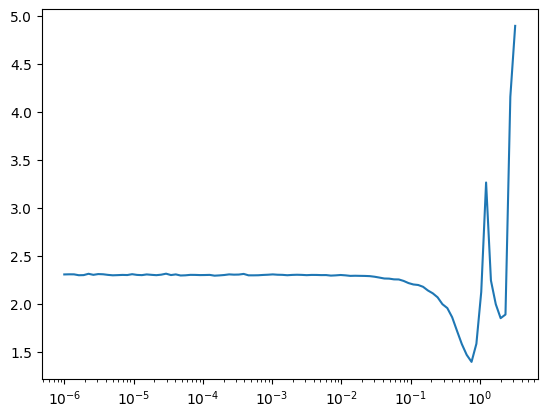

In [30]:
run.recorder.plot(skip_last=5)

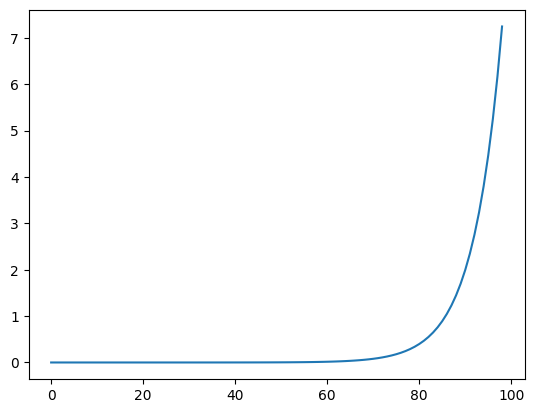

In [31]:
run.recorder.plot_lr()

now we have a lr finder